In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [3]:
!kaggle datasets download -d gpiosenka/cards-image-datasetclassification

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification
License(s): CC0-1.0
100% 385M/385M [00:22<00:00, 17.7MB/s]



In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/cards-image-datasetclassification.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

#Check the data of Test and Train folder


In [5]:
train = '/content/cards/train'
test = '/content/cards/test'

In [6]:
import os

print("Contents of /content:")
print(os.listdir('/content'))

Contents of /content:
['.config', 'cards.csv', 'train', '53cards-53-(200 X 200)-100.00.h5', 'kaggle.json', 'valid', 'test', '14card types-14-(200 X 200)-94.61.h5', 'cards-image-datasetclassification.zip', 'sample_data']


In [9]:
# generators
train_ds =  keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

test_ds =  keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)


Found 7624 files belonging to 53 classes.
Found 265 files belonging to 53 classes.


In [10]:
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/valid',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)


Found 265 files belonging to 53 classes.


In [11]:
# We have 53 classes. How can i see that which vlass is assinged ehich integer ?
for i, class_name in enumerate(train_ds.class_names):
    print(f"Integer: {i}, Class Name: {class_name}")

Integer: 0, Class Name: ace of clubs
Integer: 1, Class Name: ace of diamonds
Integer: 2, Class Name: ace of hearts
Integer: 3, Class Name: ace of spades
Integer: 4, Class Name: eight of clubs
Integer: 5, Class Name: eight of diamonds
Integer: 6, Class Name: eight of hearts
Integer: 7, Class Name: eight of spades
Integer: 8, Class Name: five of clubs
Integer: 9, Class Name: five of diamonds
Integer: 10, Class Name: five of hearts
Integer: 11, Class Name: five of spades
Integer: 12, Class Name: four of clubs
Integer: 13, Class Name: four of diamonds
Integer: 14, Class Name: four of hearts
Integer: 15, Class Name: four of spades
Integer: 16, Class Name: jack of clubs
Integer: 17, Class Name: jack of diamonds
Integer: 18, Class Name: jack of hearts
Integer: 19, Class Name: jack of spades
Integer: 20, Class Name: joker
Integer: 21, Class Name: king of clubs
Integer: 22, Class Name: king of diamonds
Integer: 23, Class Name: king of hearts
Integer: 24, Class Name: king of spades
Integer: 25, 

In [12]:
# Normalize Data
def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)
validation_ds = validation_ds.map(process)

#Making our own model....(By involving our architecture)

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense,Conv2D, MaxPooling2D,Flatten

In [13]:
# Making Our Model
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides =2 ,padding='valid'))
model.add(Conv2D(64,kernel_size=(6,6),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides =2 ,padding='valid'))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(53,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 238144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    15,241,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 53)             │         1,749 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,319,797 (58.44 MB)

 Trainable params: 15,319,797 (58.44 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(train_ds,epochs = 100,validation_data=validation_ds)

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.6149 - loss: 0.0717 - val_accuracy: 0.3509 - val_loss: 2.9644
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.6549 - loss: 0.0806 - val_accuracy: 0.3736 - val_loss: 3.2560
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.6411 - loss: 0.0585 - val_accuracy: 0.3585 - val_loss: 3.0748
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.6515 - loss: 0.0676 - val_accuracy: 0.3245 - val_loss: 2.9752
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.6489 - loss: 0.0733 - val_accuracy: 0.3811 - val_loss: 2.6334
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.6493 - loss: 0.0607 - val_accuracy: 0.3132 - val_loss: 3.3164
Epoch 7/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.6558 - loss: 0.0618 - val_accuracy: 0.3774 - val_loss: 2.7432
Epoch 8/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.6514 - loss: 0

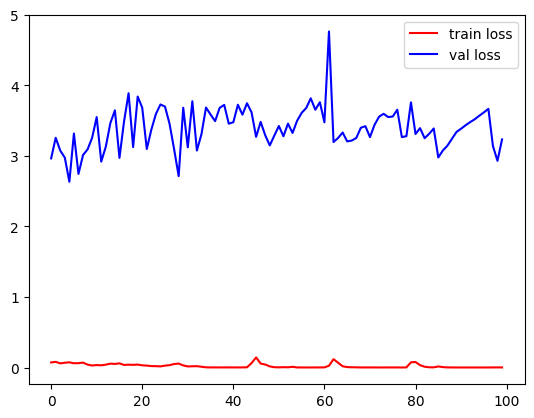

In [18]:
# By looking at this code we can say that this is a case of overfitting
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train loss')
plt.plot(history.history['val_loss'],color='blue',label='val loss')
plt.legend()
plt.show()

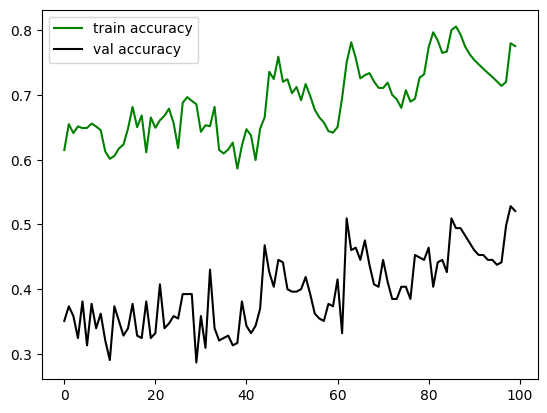

In [19]:
plt.plot(history.history['accuracy'],color='green')
plt.plot(history.history['val_accuracy'],color='black')
plt.legend(['train accuracy','val accuracy'])
plt.show ()

In [20]:
# Now check for the test data
pred = model.predict(test_ds)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


In [21]:
from sklearn.metrics import f1_score,accuracy_score,confusion_matrix
import numpy as np

In [22]:
# Extract true labels from test_ds
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Convert predictions (probabilities) to class labels
y_pred = np.argmax(pred, axis=1)

f1 = f1_score(y_true, y_pred, average='weighted') # Use 'weighted' for multi-class classification
print(f"F1 Score: {f1:.4f}")

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

F1 Score: 0.0152
Accuracy Score: 0.0151


# Now i have gone through the raw CNN architecture with only 10 epochs ... lets see with BatchNormalization and Dropout Layers with more epochs.

In [23]:
from keras.layers import BatchNormalization,Dropout

In [24]:
model_adv = Sequential()

model_adv.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model_adv.add(MaxPooling2D(pool_size=(2,2),strides =2 ,padding='valid'))
model_adv.add(BatchNormalization())

model_adv.add(Conv2D(64,kernel_size=(6,6),padding='valid',activation='relu'))
model_adv.add(MaxPooling2D(pool_size=(2,2),strides =2 ,padding='valid'))
model_adv.add(BatchNormalization())

model_adv.add(Flatten())

model_adv.add(Dense(64,activation='relu'))
model_adv.add(Dropout(0.5))
model_adv.add(Dense(32,activation='relu'))
model_adv.add(Dropout(0.4))
model_adv.add(Dense(53,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model_adv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 122, 122, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 238144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │    15,241,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 53)             │         1,749 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,320,181 (58.44 MB)

 Trainable params: 15,319,989 (58.44 MB)

 Non-trainable params: 192 (768.00 B)

In [26]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [27]:
history_adv= model.fit(train_ds, epochs =100, validation_data = validation_ds)

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.7012 - loss: 0.0104 - val_accuracy: 0.4340 - val_loss: 4.5041
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.7501 - loss: 0.0083 - val_accuracy: 0.4604 - val_loss: 4.1678
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7244 - loss: 0.0077 - val_accuracy: 0.4981 - val_loss: 4.2522
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.7723 - loss: 0.0091 - val_accuracy: 0.4189 - val_loss: 4.6555
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.7451 - loss: 0.0103 - val_accuracy: 0.4075 - val_loss: 5.0254
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.7669 - loss: 0.0260 - val_accuracy: 0.4151 - val_loss: 4.7718
Epoch 7/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8095 - loss: 0.0183 - val_accuracy: 0.4679 - val_loss: 4.1297
Epoch 8/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.7903 - loss: 0

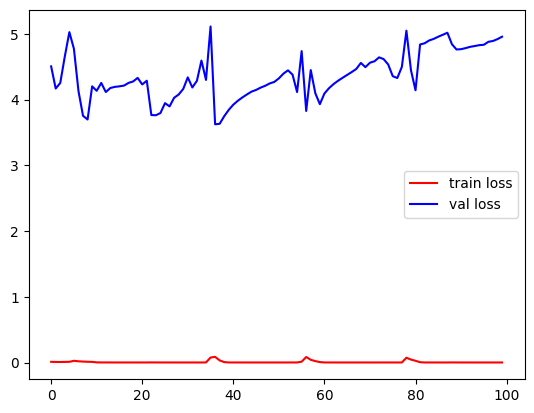

In [28]:
# It's reduce it little bit but we need to train it more...
plt.plot(history_adv.history['loss'],color='red',label='train loss')
plt.plot(history_adv.history['val_loss'],color='blue',label='val loss')
plt.legend()
plt.show()

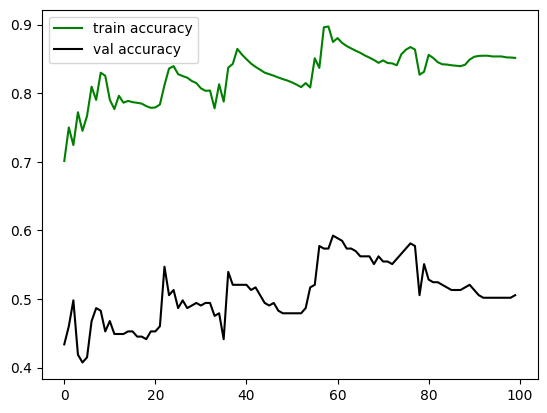

In [29]:
plt.plot(history_adv.history['accuracy'],color='green')
plt.plot(history_adv.history['val_accuracy'],color='black')
plt.legend(['train accuracy','val accuracy'])
plt.show ()


In [30]:
pred = model_adv.predict(test_ds)
y_pred_adv = np.argmax(pred, axis=1)

f1 = f1_score(y_true, y_pred_adv, average='weighted') # Use 'weighted' for multi-class classification
print(f"F1 Score: {f1:.4f}")

accuracy = accuracy_score(y_true, y_pred_adv)
print(f"Accuracy Score: {accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
F1 Score: 0.0083
Accuracy Score: 0.0226


# Now i am going to use those pretrained model which are used in imagenet like VGG16, ResNet  with Transfer learning etc....
#1. VGG16
#2. ResNet
# In these two thier have no cards model...So we have to train atleast one hidden layer of convolution model. In the notebook named "CNN_card_detection_transfer_learning" we used PRETRAIN models